# Binary Tree Tensor Network (TTN) Born Machine — Heston Paths

This notebook trains a **Binary Tree Tensor Network (BTT)** Born machine on
Heston simulated price paths, using the same data generation and encoding as
`paper_reproduction.ipynb`.

The trained model is saved to `ttn_heston.jld2` so it can be loaded and
compared with the MPS model in a separate comparison notebook.

**Architecture recap**:
- Heap-indexed balanced binary tree with `N_pad = nextpow(2, M)` leaves
- All nodes upward-isometric (root-canonical form) before each gradient step
- Per-node Adam with cosine learning-rate schedule and validation early-stopping
- Exact ancestral sampling via sequential conditional probabilities


## 1. Environment Setup

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast, MPSFast.Encoders
using Random, Statistics, LinearAlgebra, Printf
using Plots


  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`
Precompiling packages...
   2963.4 ms  ✓ MPSFast
  1 dependency successfully precompiled in 5 seconds. 306 already precompiled.


### TTN Visualization Helper

`plot_ttn_structure` renders the heap-indexed binary tree of any `BinaryTTN` object:

- **Red circles** — physical leaf tensors $A_j \in \mathbb{R}^{d \times \chi}$ (one per time step)
- **Grey circles** — padding leaves (bond-dim 1, fixed to $|0\rangle$)
- **Blue circles** — internal tensors $B_h \in \mathbb{R}^{\chi_l \times \chi_r \times \chi_u}$
- **Edge labels** — bond dimension $\chi$ on each leg (toggle with `show_bond_dims`)

In [2]:
"""
    plot_ttn_structure(ttn::BinaryTTN; kwargs...) → Plots.Plot

Visualise the heap-indexed binary-tree graph of a `BinaryTTN`.

# Keyword arguments
- `title_str`      : plot title (auto-generated from `ttn` fields if not supplied)
- `show_bond_dims` : annotate each edge with its bond dimension (default `true`)
- `figsize`        : `(width, height)` in pixels passed to Plots (default `(1000, 520)`)
"""
function plot_ttn_structure(
    ttn::BinaryTTN;
    title_str::String  = "TTN  (n_sites=$(ttn.n_sites), N_pad=$(ttn.N_pad), D_max=$(ttn.D_max))",
    show_bond_dims::Bool = true,
    figsize              = (1000, 520),
)
    N_pad   = ttn.N_pad
    n_sites = ttn.n_sites
    D       = Int(round(log2(N_pad)))   # tree depth (leaves at depth D from root)

    # ── 1. Compute (x, y) position for every heap node ───────────────────────
    # Leaves evenly spaced at y = 0.  Root at y = 1.
    pos = Dict{Int, NTuple{2,Float64}}()
    for j in 1:N_pad
        pos[N_pad + j - 1] = ((j - 0.5) / N_pad, 0.0)
    end
    for d in (D - 1):-1:0                     # bottom-up
        for h in 2^d : 2^(d+1) - 1
            xl = pos[2h][1];  xr = pos[2h+1][1]
            pos[h] = ((xl + xr) / 2, (D - d) / D)
        end
    end

    # ── 2. Canvas ─────────────────────────────────────────────────────────────
    p = Plots.plot(;
        title      = title_str,
        titleloc   = :center,
        titlefont  = (12, :bold),
        size       = figsize,
        framestyle = :none,
        legend     = false,
        xlims      = (-0.02, 1.02),
        ylims      = (-0.25, 1.18),
        grid       = false,
    )

    # ── 3. Draw edges (parent → children) ─────────────────────────────────────
    for h in 1:(N_pad - 1)
        xp, yp = pos[h]
        B      = ttn.internals[h]
        for (hc, χ_bond) in ((2h, size(B, 1)), (2h + 1, size(B, 2)))
            xc, yc = pos[hc]
            Plots.plot!(p, [xp, xc], [yp, yc]; color = :gray65, lw = 1.8, label = nothing)
            if show_bond_dims
                mx = (xp + xc) / 2;  my = (yp + yc) / 2
                # Perpendicular offset keeps label off the line
                dx = xc - xp;  dy = yc - yp
                ℓ  = sqrt(dx^2 + dy^2)
                ox = -(dy / ℓ) * 0.020;  oy = (dx / ℓ) * 0.020
                Plots.annotate!(p, mx + ox, my + oy,
                                Plots.text("χ=$χ_bond", 6, :gray35, :center))
            end
        end
    end

    # ── 4. Draw internal nodes (blue) ─────────────────────────────────────────
    for h in 1:(N_pad - 1)
        x, y         = pos[h]
        χ_l, χ_r, χ_u = size(ttn.internals[h])
        top_lbl      = h == 1 ? "root" : "h=$h"

        Plots.scatter!(p, [x], [y];
                       markersize        = 14,
                       markershape       = :circle,
                       markercolor       = :steelblue,
                       markerstrokecolor = :white,
                       markerstrokewidth = 2,
                       label             = nothing)
        Plots.annotate!(p, x, y + 0.075,
                        Plots.text(top_lbl, 7, :steelblue, :center, :bold))
        if show_bond_dims
            Plots.annotate!(p, x, y + 0.028,
                            Plots.text("($χ_l×$χ_r×$χ_u)", 5, :gray45, :center))
        end
    end

    # ── 5. Draw leaf nodes (red = real, grey = padding) ───────────────────────
    for j in 1:N_pad
        h         = N_pad + j - 1
        x, y      = pos[h]
        is_real   = j <= n_sites
        d_j, χ_j  = size(ttn.leaves[j])
        color     = is_real ? :tomato    : :lightgray
        lbl_color = is_real ? :firebrick : :gray55
        lbl       = is_real ? "t=$j"     : "pad"

        Plots.scatter!(p, [x], [y];
                       markersize        = 11,
                       markershape       = :circle,
                       markercolor       = color,
                       markerstrokecolor = :white,
                       markerstrokewidth = 2,
                       label             = nothing)
        Plots.annotate!(p, x, y - 0.055,
                        Plots.text(lbl, 7, lbl_color, :center, :bold))
        if show_bond_dims && is_real
            Plots.annotate!(p, x, y - 0.105,
                            Plots.text("(d=$d_j,χ=$χ_j)", 5, :gray50, :center))
        end
    end

    return p
end

plot_ttn_structure

## 2. Heston Model Simulation

Same parameters as `paper_reproduction.ipynb` for apples-to-apples comparison.

In [3]:
"""
    simulate_heston(N, M; S0, V0, κ, θ, ξ, ρ, r, dt, rng)

Generate `N` paths of `M` steps under the Heston stochastic volatility model
using a simple Euler-Maruyama discretisation.
"""
function simulate_heston(
    N::Int, M::Int;
    S0 = 100.0, V0 = 0.04, κ = 2.0, θ = 0.04,
    ξ = 0.3, ρ = -0.7, r = 0.0, dt = 1/252,
    rng = Random.default_rng(),
)
    S = Matrix{Float64}(undef, N, M)
    V = Matrix{Float64}(undef, N, M)
    for i in 1:N
        s = S0;  v = V0
        for t in 1:M
            z1 = randn(rng);  z2 = randn(rng)
            w1 = z1
            w2 = ρ * z1 + sqrt(1 - ρ^2) * z2
            v  = max(v + κ * (θ - v) * dt + ξ * sqrt(max(v, 0.0) * dt) * w2, 0.0)
            s  = s * exp((r - 0.5 * v) * dt + sqrt(max(v, 0.0) * dt) * w1)
            S[i, t] = s
            V[i, t] = v
        end
    end
    return S, V
end

rng     = MersenneTwister(2024)
N_train = 10_000
M       = 8

paths, paths_ν = simulate_heston(N_train, M; rng = rng)
println("Heston paths: ", size(paths))
println("Mean S[M]  : ", round(mean(paths[:, M]), digits=2))
println("Std  S[M]  : ", round(std(paths[:, M]),  digits=2))


Heston paths: (10000, 8)
Mean S[M]  : 99.65
Std  S[M]  : 3.57


## 3. Encode with BasisEncoder

In [4]:
m   = 4    # local dimension d = 2^m = 16 buckets per timestep
enc = BasisEncoder(m)
fit_grid!(enc, paths)
xi  = encode_paths(enc, paths)

encoder_summary(enc, M, 200)
println("xi range: ", extrema(xi))
println("d = $(site_dim(enc)),  M = $M")


┌ Info: Encoder
│   encoder = BasisEncoder
│   M = 8
│   chain_length = 8
│   site_dim = 16
│   D_max = 200
│   params = 3846400
└ @ MPSFast.Encoders /Users/bi006881/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/src/Encoders.jl:414


xi range: (1, 16)
d = 16,  M = 8


## 4. Train TTN

Key hyperparameters are chosen to be **comparable** to the MPS run:
- Same bond dimension `D_max`
- Same number of epochs and learning rate
- Same validation split and early-stopping patience


In [5]:
D_max_ttn = 64        # TTN bonds saturate faster than MPS; 64 is comparable to MPS χ=150
n_epochs  = 200
η         = 5e-4

# ── Validation split (10 %) ────────────────────────────────────────────────
val_frac  = 0.10
N_total   = size(xi, 1)
N_val     = round(Int, val_frac * N_total)
perm      = randperm(MersenneTwister(0), N_total)
xi_val    = xi[perm[1:N_val],        :]
xi_tr     = xi[perm[N_val+1:end],    :]
println("Train: $(size(xi_tr,1)) paths   Val: $(size(xi_val,1)) paths")

# ── Initialise TTN ─────────────────────────────────────────────────────────
ttn = init_ttn(M, site_dim(enc), D_max_ttn; T = Float32, rng = MersenneTwister(1))
println("TTN: n_sites=$(ttn.n_sites), N_pad=$(ttn.N_pad), D_max=$(ttn.D_max)")
println("     leaves:    ", [size(ttn.leaves[j]) for j in 1:ttn.N_pad if ttn.d_vec[j] > 1])
println("     internals: ", [size(ttn.internals[i]) for i in 1:ttn.N_pad-1])

# ── Train ──────────────────────────────────────────────────────────────────
ttn_val_nll = Float64[]
ttn_nll_hist = train_ttn!(
    ttn, xi_tr, n_epochs, η, D_max_ttn;
    verbose          = true,
    nll_samples      = 5_000,
    lr_schedule      = cosine_lr,
    val_data         = xi_val,
    val_samples      = 2_000,
    patience         = 15,
    val_nll_log      = ttn_val_nll,
)


Train: 9000 paths   Val: 1000 paths
TTN: n_sites=8, N_pad=8, D_max=64
     leaves:    [(16, 16), (16, 16), (16, 16), (16, 16), (16, 16), (16, 16), (16, 16), (16, 16)]
     internals: [(64, 64, 1), (64, 64, 64), (64, 64, 64), (16, 16, 64), (16, 16, 64), (16, 16, 64), (16, 16, 64)]
train_ttn!: n_sites=8, N_pad=8, D_max=64, epochs=200, sweep=zigzag, dmrg_pairs=true
Epoch 1/200 | TTN NLL ≈ 22.4299 | η=0.0005 | 7.86 s
  ↳ val NLL ≈ 22.7181  (patience 0/15)
Epoch 2/200 | TTN NLL ≈ 21.7091 | η=0.0005 | 6.99 s
  ↳ val NLL ≈ 22.0916  (patience 0/15)
Epoch 3/200 | TTN NLL ≈ 21.1346 | η=0.0005 | 6.34 s
  ↳ val NLL ≈ 21.5262  (patience 0/15)
Epoch 4/200 | TTN NLL ≈ 20.6361 | η=0.0005 | 6.85 s
  ↳ val NLL ≈ 21.0584  (patience 0/15)
Epoch 5/200 | TTN NLL ≈ 20.1492 | η=0.0005 | 5.43 s
  ↳ val NLL ≈ 20.614  (patience 0/15)
Epoch 6/200 | TTN NLL ≈ 19.7924 | η=0.000499 | 6.05 s
  ↳ val NLL ≈ 20.2895  (patience 0/15)
Epoch 7/200 | TTN NLL ≈ 19.478 | η=0.000499 | 5.43 s
  ↳ val NLL ≈ 19.9921  (patience 0/

200-element Vector{Float64}:
 22.429926200682477
 21.70908309496691
 21.13457797889009
 20.636140717714422
 20.149164487753843
 19.792394283948045
 19.478011864911547
 19.162758590871874
 18.874214771096305
 18.581407876023007
  ⋮
 10.406905315623101
 10.387465113137782
 10.431288584925232
 10.41948469147904
 10.408233060609147
 10.385178947285857
 10.392682530519032
 10.418766797826265
 10.438612045429586

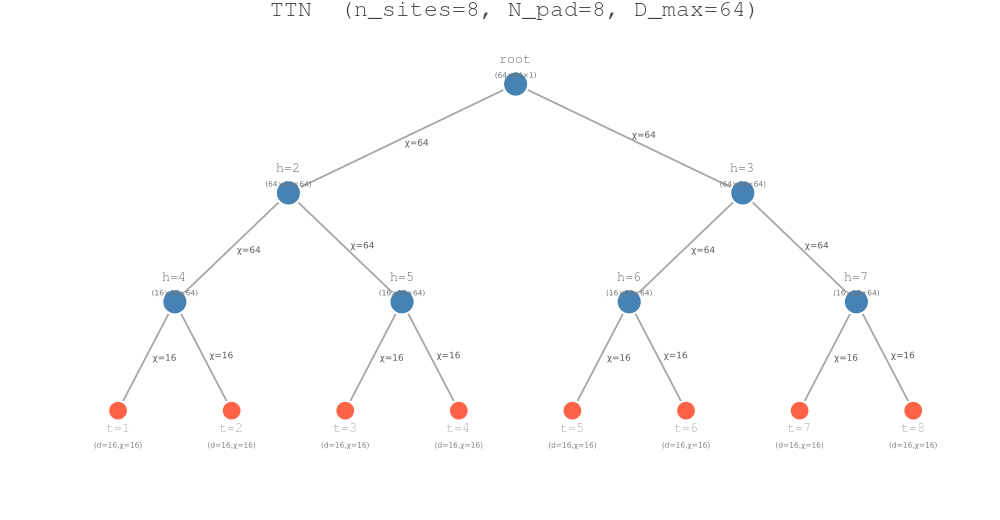

GKS: could not find font bold.ttf


In [6]:
# ── Show TTN architecture diagram ─────────────────────────────────────────
# Visualise the trained TTN: bond dimensions reflect the truncated structure.
# Red  = physical time-step leaves (t=1…n_sites)
# Grey = padding leaves (fixed |0⟩, trivial bond dim 1)
# Blue = internal contraction nodes
plot_ttn_structure(ttn)

## 5. Training Convergence

Epoch  Train-NLL  Val-NLL
1       22.4299     22.7181
2       21.7091     22.0916
3       21.1346     21.5262
4       20.6361     21.0584
5       20.1492     20.6140
6       19.7924     20.2895
7       19.4780     19.9921
8       19.1628     19.7310
9       18.8742     19.4292
10      18.5814     19.1459
11      18.2676     18.8702
12      18.0408     18.6284
13      17.7931     18.3627
14      17.5904     18.1181
15      17.3621     17.8870
16      17.1079     17.6764
17      16.8721     17.4501
18      16.6954     17.2445
19      16.5065     17.0651
20      16.2717     16.8876
21      16.1019     16.7107
22      15.8997     16.5236
23      15.7230     16.3494
24      15.5484     16.1700
25      15.3605     15.9948
26      15.1622     15.8185
27      15.0431     15.6754
28      14.9280     15.5434
29      14.7513     15.4274
30      14.5894     15.2857
31      14.5419     15.1595
32      14.3647     15.0300
33      14.2603     14.9105
34      14.1783     14.7991
35      13.9848     14

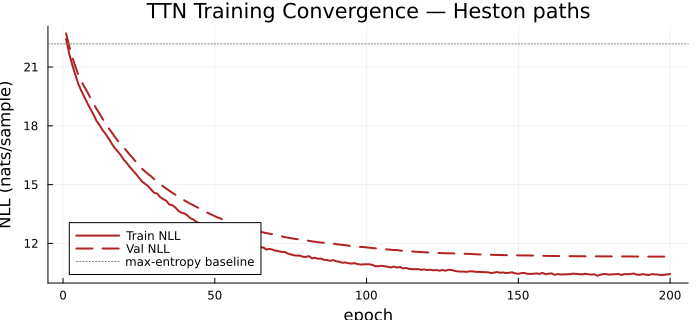

In [7]:
# NLL table
println("Epoch  Train-NLL  Val-NLL")
for e in 1:length(ttn_nll_hist)
    vv = e <= length(ttn_val_nll) ? @sprintf("%.4f", ttn_val_nll[e]) : "—"
    @printf("%-6d  %.4f     %s\n", e, ttn_nll_hist[e], vv)
end

# ── Figure: TTN training convergence ──────────────────────────────────────
p_nll = plot(1:length(ttn_nll_hist), ttn_nll_hist;
    label="Train NLL", lw=2, color=:firebrick,
    xlabel="epoch", ylabel="NLL (nats/sample)",
    title="TTN Training Convergence — Heston paths", size=(700, 320))
if !isempty(ttn_val_nll)
    plot!(p_nll, 1:length(ttn_val_nll), ttn_val_nll;
        label="Val NLL", lw=2, ls=:dash, color=:firebrick)
end
hline!(p_nll, [log(site_dim(enc)^M)];
    label="max-entropy baseline", ls=:dot, color=:grey)
display(p_nll)


## 6. Sample New Paths from TTN

In [10]:
global N_samp = 5_000
ttn_paths, ttn_xi = sample_ttn(enc, ttn, N_samp; seed = 7)
println("Sampled paths shape: ", size(ttn_paths))

# ── Marginal table ─────────────────────────────────────────────────────────
println("\n  t   Heston mean  TTN mean   Heston std   TTN std")
for t in filter(t -> t <= M, [1, 5, 10, 20, 30])
    @printf("  %-3d  %9.3f   %9.3f   %9.3f   %9.3f\n", t,
            mean(paths[:,t]),     mean(ttn_paths[:,t]),
            std(paths[:,t]),      std(ttn_paths[:,t]))
end


Sampled paths shape: (5000, 8)

  t   Heston mean  TTN mean   Heston std   TTN std
  1       99.962      99.057       1.259       3.687
  5       99.765      98.953       2.827       4.363


## 7. Visualisation

Requires the trained `ttn` and encoder `enc` from above. If section 6 was not run in this session, this cell will sample 5 000 paths automatically before plotting.

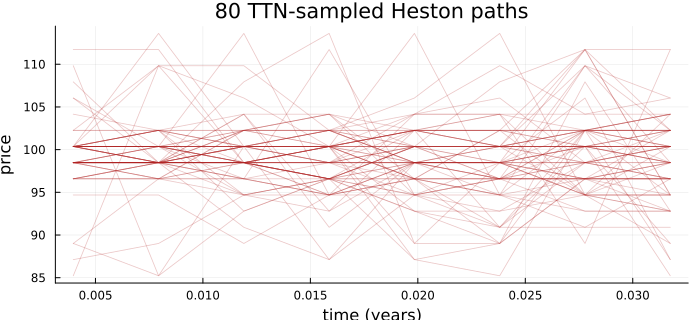

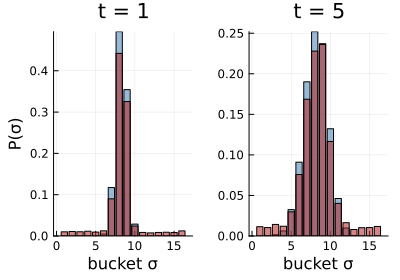

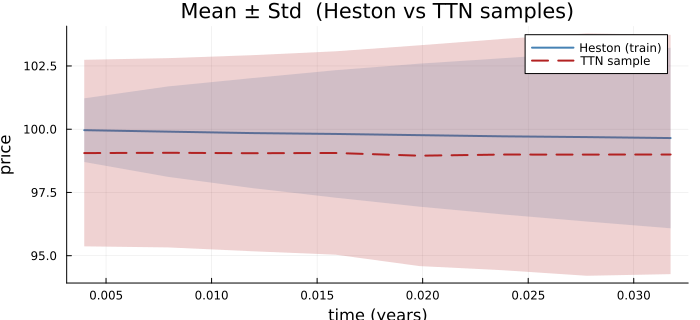

In [11]:
# Sample if section 6 was not run in this kernel session
if !isdefined(Main, :ttn_paths) || !isdefined(Main, :ttn_xi)
    N_samp = get(Main, :N_samp, 5_000)
    println("Sampling $N_samp TTN paths (run section 6 first to skip this)…")
    global ttn_paths, ttn_xi = sample_ttn(enc, ttn, N_samp; seed = 7)
    println("Sampled paths shape: ", size(ttn_paths))
end

ts = (1:M) ./ 252

# ── Figure A: example sampled paths ───────────────────────────────────────
p_paths = plot(ts, ttn_paths[1:80, :]';
    color=:firebrick, alpha=0.25, lw=0.8, label=false,
    xlabel="time (years)", ylabel="price",
    title="80 TTN-sampled Heston paths", size=(700, 320))
display(p_paths)

# ── Figure B: marginal distributions at selected time steps ───────────────
d_enc      = site_dim(enc)
times_show = filter(t -> t <= M, [1, 5, 10, 20, 30])
train_marg = [count(==(σ), xi[:,t])     / N_train for σ in 1:d_enc, t in 1:M]
ttn_marg   = [count(==(σ), ttn_xi[:,t]) / size(ttn_xi, 1) for σ in 1:d_enc, t in 1:M]

p_marg = plot(layout=(1, length(times_show)),
              size=(200 * length(times_show), 280),
              title=reshape(["t = $t" for t in times_show], 1, :),
              legend=false)
for (k, t) in enumerate(times_show)
    bar!(p_marg, subplot=k, 1:d_enc, train_marg[:, t];
         fillalpha=0.55, color=:steelblue, label="train",
         xlabel="bucket σ", ylabel=k==1 ? "P(σ)" : "")
    bar!(p_marg, subplot=k, 1:d_enc, ttn_marg[:, t];
         fillalpha=0.55, color=:firebrick, label="TTN")
end
display(p_marg)

# ── Figure C: per-timestep mean ± std ─────────────────────────────────────
train_μ = vec(mean(paths,     dims=1))
ttn_μ   = vec(mean(ttn_paths, dims=1))
train_σ = vec(std(paths,      dims=1))
ttn_σ   = vec(std(ttn_paths,  dims=1))

p_stats = plot(ts, train_μ; ribbon=train_σ, fillalpha=0.2,
    label="Heston (train)", color=:steelblue, lw=2,
    xlabel="time (years)", ylabel="price",
    title="Mean ± Std  (Heston vs TTN samples)", size=(700, 320))
plot!(p_stats, ts, ttn_μ; ribbon=ttn_σ, fillalpha=0.2,
    label="TTN sample", color=:firebrick, lw=2, ls=:dash)
display(p_stats)


## 8. Save TTN Bundle

Saves the trained TTN and metadata to `ttn_heston.jld2` so the comparison
notebook can load it alongside `mps_heston.jld2` without re-training.


In [13]:
using JLD2

ttn_meta = Dict{String,Any}(
    "N_train"     => N_train,
    "M"           => M,
    "m"           => m,
    "D_max"       => D_max_ttn,
    "n_epochs"    => n_epochs,
    "encoder"     => string(typeof(enc)),
    "Smin"        => enc.Smin,
    "Smax"        => enc.Smax,
)

@save "ttn_heston.jld2" ttn ttn_nll_hist ttn_val_nll ttn_meta
println("Saved → ttn_heston.jld2")

# Sanity-reload
@load "ttn_heston.jld2" ttn ttn_nll_hist ttn_val_nll ttn_meta
println("Reloaded: final train NLL = ", round(ttn_nll_hist[end]; digits=4))


Saved → ttn_heston.jld2
Reloaded: final train NLL = 10.4386
